# Climatology & Anomaly Analysis — E3\_pole\_tower

**Purpose:** Assess the contribution of weather anomalies vs climatological
means to wildfire ignition predictions.

Two counterfactual experiments using the E3\_pole\_tower model:

| Experiment | What changes | Question answered |
|:-----------|:-------------|:------------------|
| **CLIM** | Weather features replaced with 20-yr monthly climatology | What if weather had no inter-annual variability? |
| **ANOM** | Weather features replaced with anomalies (actual − climatology) | What do weather departures alone contribute? |

Both experiments keep non-weather features (veg, slope, road, power
infrastructure, prev\_fire, LAI, wind direction) at their actual values.

## 0. Configuration

In [2]:
import os

# ======================== PATHS ========================
DATA_ROOT    = r"E:\zcao\CA_Wildfire"
DATA_VERSION = "Monthly_03152026_calibration"
DATA_DIR     = os.path.join(DATA_ROOT, "Clean_Data", "Model_Data",
                            "Evaluation", "Features_w_Label", DATA_VERSION)

PROJECT_ROOT = r"E:\zcao\Ignition - ML Modeling"

# ---------- Experiment to analyse ----------
EXP_NAME    = "E3_pole_tower"
LEN_TRAIN   = 6
TAG         = f"{EXP_NAME}__LT{LEN_TRAIN}"

MODEL_DIR   = os.path.join(PROJECT_ROOT, "Models", TAG)
PLOT_DIR    = os.path.join(PROJECT_ROOT, "Plots", TAG, "Climate")
CLIM_DIR    = os.path.join(DATA_ROOT, "Clean_Data", "climatology")

# Output dirs for counterfactual predictions
OUTPUT_CLIM = os.path.join(PROJECT_ROOT, "Predictions", TAG, "CLIM")
OUTPUT_ANOM = os.path.join(PROJECT_ROOT, "Predictions", TAG, "ANOM")

for d in [PLOT_DIR, CLIM_DIR, OUTPUT_CLIM, OUTPUT_ANOM]:
    os.makedirs(d, exist_ok=True)

LABEL_COL     = "IS_FIRE"
PREDICT_YEARS = list(range(2001, 2021))

print(f"Data dir  : {DATA_DIR}")
print(f"Model dir : {MODEL_DIR}")
print(f"CLIM out  : {OUTPUT_CLIM}")
print(f"ANOM out  : {OUTPUT_ANOM}")

Data dir  : E:\zcao\CA_Wildfire\Clean_Data\Model_Data\Evaluation\Features_w_Label\Monthly_03152026_calibration
Model dir : E:\zcao\Ignition - ML Modeling\Models\E3_pole_tower__LT6
CLIM out  : E:\zcao\Ignition - ML Modeling\Predictions\E3_pole_tower__LT6\CLIM
ANOM out  : E:\zcao\Ignition - ML Modeling\Predictions\E3_pole_tower__LT6\ANOM


## 1. Imports

In [3]:
import sys, gc, warnings, pickle, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import spearmanr

def get_base_model(cal_model):
    """Extract the underlying XGBoost estimator from CalibratedClassifierCV."""
    return getattr(cal_model, "estimator",
                   getattr(cal_model, "base_estimator", None))

## 2. Load & Prepare Data

In [4]:
# --- Load non-calibration split -----------------------------------------
mod_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_non_calibration.parquet"))

# --- Rename octant day-count cols ----------------------------------------
octant_dirs = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
rename_map  = {f"wind_direction_category_{d}": f"wind_direction_category_{d}_freq"
               for d in octant_dirs}
mod_data = mod_data.rename(columns=rename_map)

# --- One-hot encode categoricals ----------------------------------------
cat_cols = ["veg_group", "wind_direction_category"]
mod_data = pd.get_dummies(mod_data, columns=cat_cols)

# --- Derive month column ------------------------------------------------
if "month" not in mod_data.columns:
    mod_data["month"] = mod_data["year_month"].dt.month

print(f"Non-calibration: {mod_data.shape}")
print(f"Year-month range: {mod_data['year_month'].min()} – {mod_data['year_month'].max()}")

Non-calibration: (3396205, 81)
Year-month range: 1994-01 – 2020-09


## 3. Define Weather Features for Climatology

In [5]:
# These are the weather/climate features whose climatology we compute.
# Non-weather features (veg, slope, road, power, prev_fire, wind direction
# one-hot, LAI) stay at their actual values in both experiments.
weather_features = [
    "dead_fuel_moisture_1000hr",
    "dead_fuel_moisture_100hr",
    "max_air_temperature",
    "max_relative_humidity",
    "min_air_temperature",
    "min_relative_humidity",
    "precipitation_amount",
    "specific_humidity",
    "surface_downwelling_shortwave_flux_in_air",
    "wind_speed",
    "SWE",
]

# Verify all present
missing = [f for f in weather_features if f not in mod_data.columns]
print(f"Weather features: {len(weather_features)}")
if missing:
    print(f"WARNING — missing: {missing}")
else:
    print("All present. ✓")

Weather features: 11
All present. ✓


---
# Part 1 — Compute Monthly Climatology

20-year monthly mean (WY 2001–2020) of each weather feature per grid cell,
computed from the non-calibration split only.

In [6]:
# Filter to WY 2001–2020 (Oct 2000 – Sep 2020)
clim_data = mod_data[
    (mod_data["year_month"] >= "2000-10") &
    (mod_data["year_month"] <= "2020-09")
].copy()

print(f"Climatology input: {clim_data.shape[0]:,} rows")
print(f"  Date range: {clim_data['year_month'].min()} – {clim_data['year_month'].max()}")

# Compute per (lon, lat, month) mean
climatology = (
    clim_data.groupby(["lon", "lat", "month"])[weather_features]
    .mean()
    .reset_index()
)

print(f"Climatology grid: {climatology.shape[0]:,} (lon, lat, month) combos")

# Save
clim_path = os.path.join(CLIM_DIR,
    "climatology_2001_2020_monthly_exclude_calibration.parquet")
climatology.to_parquet(clim_path, index=False)
print(f"Saved to: {clim_path}")

# Validate uniqueness
assert climatology[["lon", "lat", "month"]].drop_duplicates().shape[0] ==        climatology.shape[0], "lon/lat/month should be unique"
print("Uniqueness check passed. ✓")

del clim_data
gc.collect()

Climatology input: 2,542,121 rows
  Date range: 2000-10 – 2020-09
Climatology grid: 141,607 (lon, lat, month) combos
Saved to: E:\zcao\CA_Wildfire\Clean_Data\climatology\climatology_2001_2020_monthly_exclude_calibration.parquet
Uniqueness check passed. ✓


0

---
# Part 2 — Experiment CLIM: Replace Weather with Climatology

For each water year, replace all weather features with their climatological
(20-yr average) values, then re-predict. If predictions barely change,
weather variability contributes little; if they flatten, weather anomalies
are key drivers.

In [7]:
print("=== Experiment CLIM: Weather → Climatological Means ===")

# Trim climatology to just the columns we need for merging
ref_clim = climatology[["lon", "lat", "month"] + weather_features].copy()

log_clim = [f"Start: {pd.Timestamp.now()}", f"Experiment: {TAG} — CLIM",
            f"Weather features replaced with climatology: {weather_features}"]

for yr in tqdm(PREDICT_YEARS, desc="CLIM"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{yr}.pkl")
    if not os.path.exists(pkl_path):
        continue

    with open(pkl_path, "rb") as f:
        cal_model = pickle.load(f)

    model_features = get_base_model(cal_model).get_booster().feature_names

    evl = mod_data[mod_data["water_year"] == yr].copy()
    shape_before = evl.shape

    # Drop actual weather, merge in climatology
    evl = evl.drop(columns=weather_features)
    evl = evl.merge(ref_clim, on=["lon", "lat", "month"], how="inner")

    assert evl.shape[0] == shape_before[0],         f"WY {yr}: row mismatch after merge ({shape_before[0]} → {evl.shape[0]})"

    # Original prediction (already in data if available, else recompute)
    evl["predictions_original"] = cal_model.predict_proba(
        mod_data[mod_data["water_year"] == yr][model_features])[:, 1]

    # Counterfactual prediction with climatological weather
    evl["predictions_update"] = cal_model.predict_proba(evl[model_features])[:, 1]

    evl.to_parquet(os.path.join(OUTPUT_CLIM, f"{yr}_predictions.parquet"), index=False)
    log_clim.append(f"WY {yr}: {evl.shape[0]:,} rows")

    del cal_model, evl
    gc.collect()

with open(os.path.join(OUTPUT_CLIM, "log.txt"), "w") as f:
    f.write("\n".join(log_clim))

print("CLIM experiment complete.")

=== Experiment CLIM: Weather → Climatological Means ===


CLIM: 100%|██████████| 20/20 [00:28<00:00,  1.42s/it]

CLIM experiment complete.


---
# Part 3 — Experiment ANOM: Replace Weather with Anomalies

For each water year, replace weather features with their anomalies
(actual − climatology), then re-predict.  This isolates the model's
response to weather departures from the long-term mean.

In [8]:
print("=== Experiment ANOM: Weather → Anomalies (Actual − Climatology) ===")

log_anom = [f"Start: {pd.Timestamp.now()}", f"Experiment: {TAG} — ANOM",
            f"Weather features replaced with anomalies: {weather_features}"]

for yr in tqdm(PREDICT_YEARS, desc="ANOM"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{yr}.pkl")
    if not os.path.exists(pkl_path):
        continue

    with open(pkl_path, "rb") as f:
        cal_model = pickle.load(f)

    model_features = get_base_model(cal_model).get_booster().feature_names

    evl = mod_data[mod_data["water_year"] == yr].copy()
    shape_before = evl.shape

    # Merge climatology
    evl = evl.merge(ref_clim, on=["lon", "lat", "month"], how="inner",
                    suffixes=("", "_clim"))

    assert evl.shape[0] == shape_before[0],         f"WY {yr}: row mismatch after merge ({shape_before[0]} → {evl.shape[0]})"

    # Replace weather with anomaly = actual − climatology
    for var in weather_features:
        evl[var] = evl[var] - evl[f"{var}_clim"]

    # Drop climatology columns
    evl = evl.drop(columns=[f"{var}_clim" for var in weather_features])

    # Original prediction
    evl["predictions_original"] = cal_model.predict_proba(
        mod_data[mod_data["water_year"] == yr][model_features])[:, 1]

    # Counterfactual prediction with anomaly weather
    evl["predictions_update"] = cal_model.predict_proba(evl[model_features])[:, 1]

    evl.to_parquet(os.path.join(OUTPUT_ANOM, f"{yr}_predictions.parquet"), index=False)
    log_anom.append(f"WY {yr}: {evl.shape[0]:,} rows")

    del cal_model, evl
    gc.collect()

with open(os.path.join(OUTPUT_ANOM, "log.txt"), "w") as f:
    f.write("\n".join(log_anom))

print("ANOM experiment complete.")

=== Experiment ANOM: Weather → Anomalies (Actual − Climatology) ===


ANOM: 100%|██████████| 20/20 [00:27<00:00,  1.37s/it]

ANOM experiment complete.


---
# Part 4 — Seasonal Predictions vs Observed Ignitions

Three-panel plot: Original vs Climatology predictions (lines, left axis)
with observed ignition counts (bars, right axis) for Wet, Early Fire, and
Peak Fire seasons.

In [9]:
# === Load both CLIM and ANOM experiment predictions ===
print("Loading experiment predictions...")

def load_all_years(output_dir):
    dfs = []
    for yr in PREDICT_YEARS:
        fpath = os.path.join(output_dir, f"{yr}_predictions.parquet")
        if os.path.exists(fpath):
            dfs.append(pd.read_parquet(fpath))
    return pd.concat(dfs, ignore_index=True)

df_clim = load_all_years(OUTPUT_CLIM)
df_anom = load_all_years(OUTPUT_ANOM)

print(f"CLIM: {df_clim.shape[0]:,} rows")
print(f"ANOM: {df_anom.shape[0]:,} rows")

Loading experiment predictions...
CLIM: 2,542,121 rows
ANOM: 2,542,121 rows


In [11]:
# === Build seasonal_data dict for plotting ===
seasons_def = {
    'Wet':        [10, 11, 12, 1, 2, 3, 4],
    'Early Fire': [5, 6],
    'Peak Fire':  [7, 8, 9],
}

seasonal_data = {}

for season, months in seasons_def.items():
    # Original predictions — seasonal mean per water year
    orig = (df_clim[df_clim['month'].isin(months)]
            .groupby('water_year')['predictions_original']
            .mean().reset_index().rename(columns={'predictions_original': 'value'}))

    # CLIM experiment predictions
    clim = (df_clim[df_clim['month'].isin(months)]
            .groupby('water_year')['predictions_update']
            .mean().reset_index().rename(columns={'predictions_update': 'value'}))

    # ANOM experiment predictions
    anom = (df_anom[df_anom['month'].isin(months)]
            .groupby('water_year')['predictions_update']
            .mean().reset_index().rename(columns={'predictions_update': 'value'}))

    # Observed ignitions — total per water year
    ign = (df_clim[df_clim['month'].isin(months)]
           .groupby('water_year')['IS_FIRE']
           .sum().reset_index().rename(columns={'IS_FIRE': 'total_ignitions'}))

    seasonal_data[season] = {
        'orig': orig,
        'clim': clim,
        'anom': anom,
        'ign':  ign,
    }

    print(f"{season:12s}: {len(orig)} years, "
          f"ignitions {ign['total_ignitions'].min():.0f}–{ign['total_ignitions'].max():.0f}")

Wet         : 20 years, ignitions 428–1214
Early Fire  : 20 years, ignitions 293–878
Peak Fire   : 20 years, ignitions 546–1446


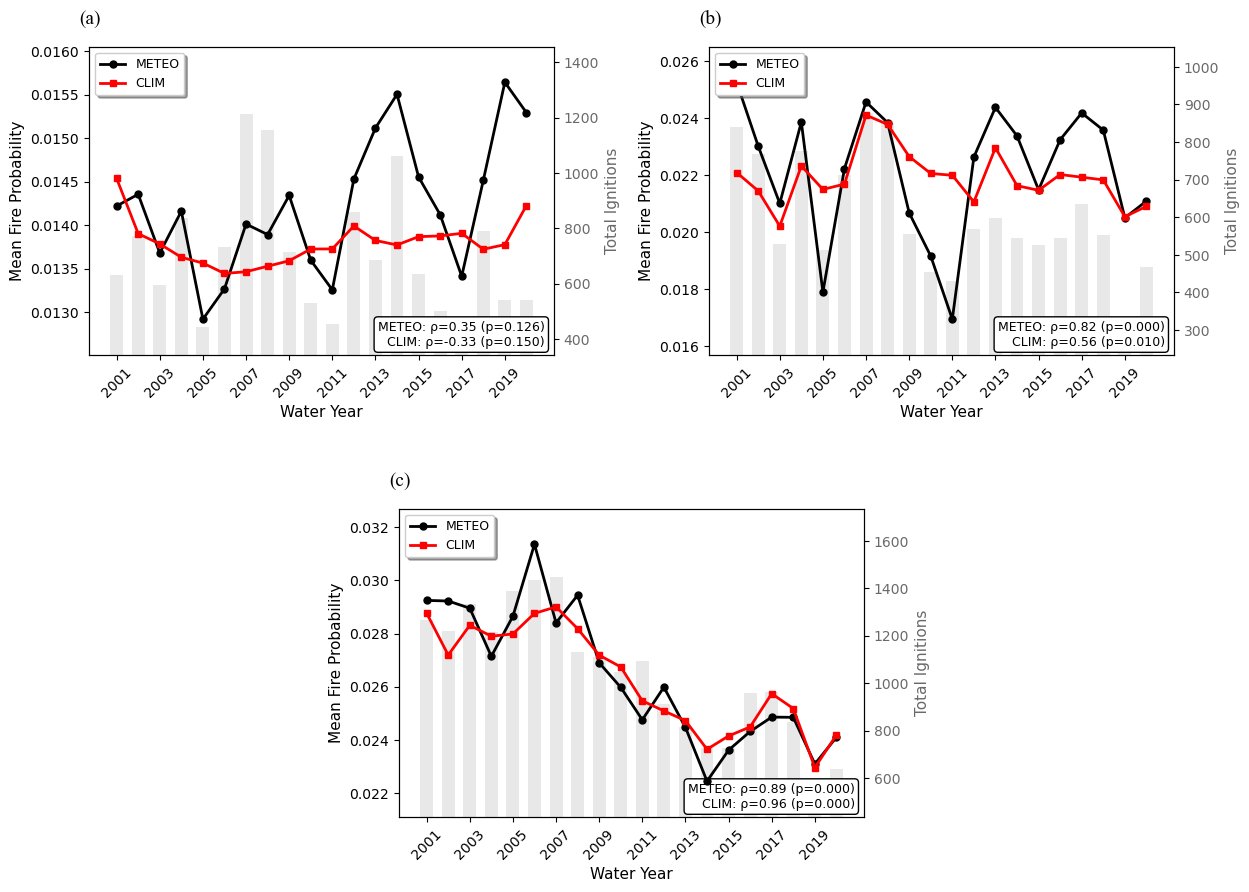

Saved CLIM figure.


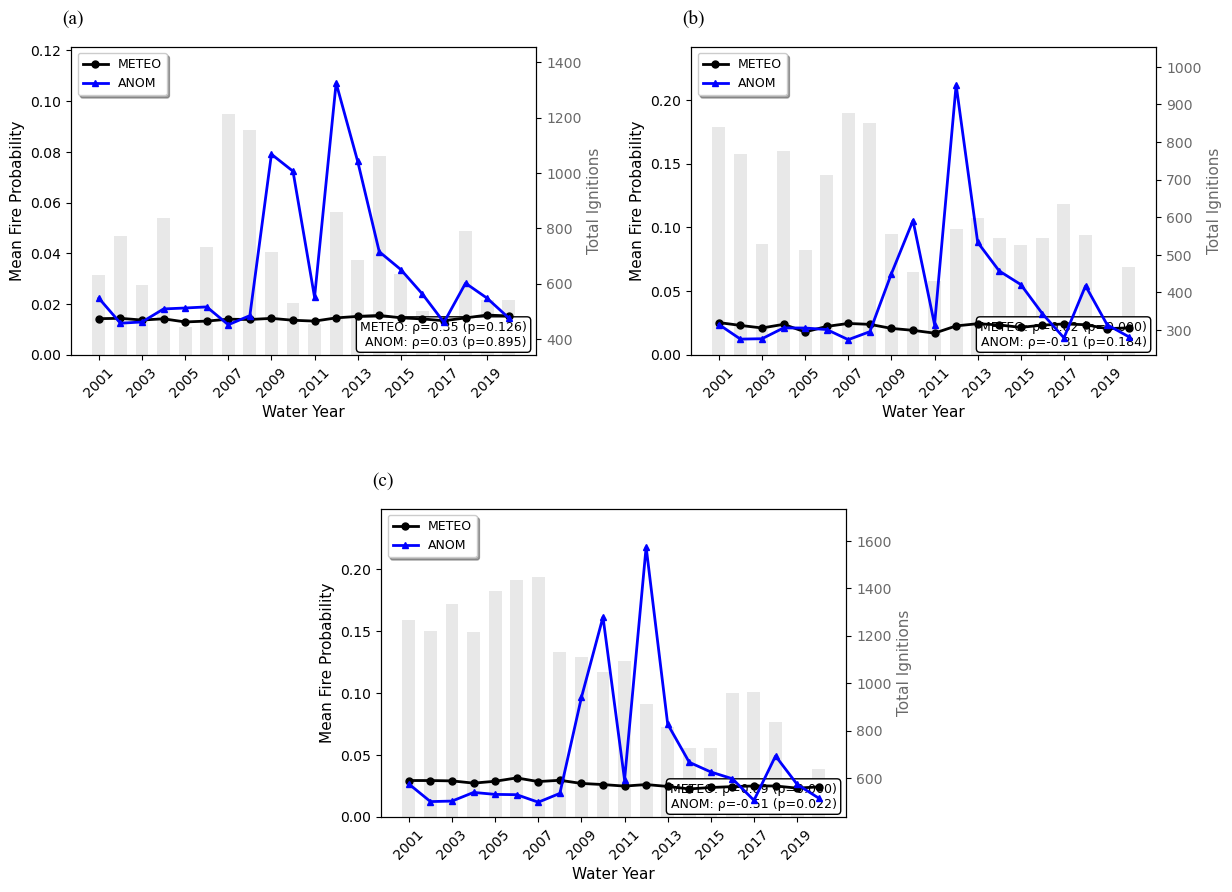

Saved ANOM figure.


In [13]:
seasons = ['Wet', 'Early Fire', 'Peak Fire']
season_months = {
    'Wet': [10, 11, 12, 1, 2, 3, 4],
    'Early Fire': [5, 6],
    'Peak Fire': [7, 8, 9],
}
panel_labels = ['(a)', '(b)', '(c)']
for exp_name, exp_color, exp_marker in [
    ("CLIM", "red",  "s"),
    ("ANOM", "blue", "^"),
]:
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 4, hspace=0.5, wspace=1)
    subplot_specs = [
        gs[0, 0:2],  # (a) top-left
        gs[0, 2:4],  # (b) top-right
        gs[1, 1:3],  # (c) bottom-center, same width as top panels
    ]
    for i, season in enumerate(seasons):
        if season not in seasonal_data:
            continue
        sd = seasonal_data[season]
        years     = sd['orig']['water_year'].values
        ctl_vals  = sd['orig']['value'].values
        exp_vals  = sd[exp_name.lower()]['value'].values
        ign_vals  = sd['ign'].set_index('water_year')['total_ignitions'].reindex(years).values
        ax1 = fig.add_subplot(subplot_specs[i])
        # Right axis — observed ignitions (bars)
        ax2 = ax1.twinx()
        ax2.bar(years, ign_vals, color='lightgray', alpha=0.5,
                label='Observed Ignitions', width=0.6)
        ax2.set_ylabel("Total Ignitions", color='dimgray', fontsize=11)
        ax2.tick_params(axis='y', labelcolor='dimgray')
        valid_ign = ign_vals[~np.isnan(ign_vals)]
        if len(valid_ign) > 0:
            ax2.set_ylim(valid_ign.min() * 0.8, valid_ign.max() * 1.2)
        # Left axis — METEO + experiment lines
        ax1.plot(years, ctl_vals, label='METEO', color='black',
                 marker='o', linewidth=2, markersize=5, zorder=5)
        ax1.plot(years, exp_vals, label=exp_name, color=exp_color,
                 marker=exp_marker, linewidth=2, markersize=5, zorder=5)
        ax1.set_ylabel("Mean Fire Probability", fontsize=11)
        ax1.set_xlabel("Water Year", fontsize=11)
        ax1.set_xticks(years[::2])
        ax1.tick_params(axis='x', rotation=45)
        ax1.set_zorder(ax2.get_zorder() + 1)
        ax1.patch.set_visible(False)
        # Tighten left axis
        all_pred = np.concatenate([ctl_vals, exp_vals])
        pred_lo, pred_hi = all_pred.min(), all_pred.max()
        pred_pad = 0.15 * (pred_hi - pred_lo) if pred_hi > pred_lo else 0.001
        ax1.set_ylim(max(0, pred_lo - pred_pad), pred_hi + pred_pad)
        # Correlation annotations
        valid_idx = ~np.isnan(ign_vals)
        if np.sum(valid_idx) > 1:
            r_orig, p_orig = spearmanr(ctl_vals[valid_idx], ign_vals[valid_idx])
            r_exp,  p_exp  = spearmanr(exp_vals[valid_idx], ign_vals[valid_idx])
            ax1.text(0.98, 0.02,
                     f'METEO: ρ={r_orig:.2f} (p={p_orig:.3f})\n'
                     f'{exp_name}: ρ={r_exp:.2f} (p={p_exp:.3f})',
                     transform=ax1.transAxes, fontsize=9,
                     verticalalignment='bottom', horizontalalignment='right',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=1))
        ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=9)
        #ax1.set_title(f"{season} Season", fontsize=12, fontweight='bold')
        ax1.grid(False)
        # Panel label
        ax1.text(-0.02, 1.12, panel_labels[i],
                 transform=ax1.transAxes, fontsize=14, 
                 fontfamily='Times New Roman',
                 verticalalignment='top', horizontalalignment='left')
    plt.savefig(os.path.join(PLOT_DIR, f"{exp_name}_Seasonal_vs_Ignitions.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {exp_name} figure.")

---
## Summary

In [ ]:
print(f"Climatology saved to : {CLIM_DIR}")
print(f"CLIM predictions     : {OUTPUT_CLIM}")
print(f"ANOM predictions     : {OUTPUT_ANOM}")
print(f"Plots saved to       : {PLOT_DIR}")

print("\nGenerated files:")
for d in [OUTPUT_CLIM, OUTPUT_ANOM, PLOT_DIR]:
    print(f"\n  {d}/")
    if os.path.isdir(d):
        for f in sorted(os.listdir(d))[:5]:
            print(f"    {f}")
        n = len(os.listdir(d))
        if n > 5:
            print(f"    ... ({n} files total)")